In [2]:
import os
import numpy as np
from util import *
import random
import gc
import tensorflow as tf
from tensorflow.keras import layers, models, Model, Input
import copy as c
import pickle
from keras.models import load_model
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tabulate import tabulate

[   INFO   ] MusicExtractorSVM: no classifier models were configured by default
I0000 00:00:1783431144.412438  971095 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
shuffle = False
seed = random.randint(1,100000)
batch_size = 32
nepochs = 100
bidirectional_audio = True
audio_to_history = True
aud_memlen = 31
memlen = 64
audio_radius = 4
narrow_types = 4
valid_txt_fp = 'sym/songs/songs_valid.txt'
sym_model = load_model('trained_models/sym_checkpoint.keras')
sym_model_ddc = load_model('trained_models/sym_ddc_checkpoint.keras')
#sym_model_diff = load_model('trained_models/sym_diff_checkpoint.keras')
#sym_model_conv3d = load_model('trained_models/sym_conv3d_checkpoint.keras')
ignore_classes = []
step_classes = []
for i in range(256):
    unhot = list(unravel_onehot(i, 4))
    if '2' not in unhot and '3' not in unhot:
        ignore_classes.append(i)
    else:
        step_classes.append(i)

I0000 00:00:1783431148.400315  971095 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3707 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:05:00.0, compute capability: 8.6


In [4]:
# Change audio_radius from 20 to 4 to match your architecture's input shape requirement
audio_radius = 4  

# Make sure aud_memlen matches your network architecture's expected timeline depth (7)
aud_memlen = 7    

# Maintain your other sequences configuration
use_diff = False
# Compile model
sym_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.AUC(from_logits=False, curve='PR'),
        tf.keras.metrics.CategoricalAccuracy(),
        tf.keras.metrics.TopKCategoricalAccuracy(k=2, name = 'top2acc'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name = 'top3acc'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=5, name = 'top5acc'),
        MaskedCategoricalAccuracy(ignore_classes),
        MaskedCategoricalAccuracy(step_classes, name='step_mask')
    ],
)

# Prepare result lists (Chart-by-chart collection)
losses_chart, AUCs_chart, Accs_chart, HoldAccs_chart, StepAccs_chart = [], [], {1:[], 2:[], 3:[], 5:[]}, [], []
accuracy_dict = {}

# Raw totals tracking (Sample-weighted prediction level tracking)
total_samples = 0
total_loss_samples = 0
total_auc_samples = 0
total_correct_samples = {1: 0.0, 2: 0.0, 3: 0.0, 5: 0.0}
total_hold_correct = 0.0
total_hold_samples = 0
total_step_correct = 0.0
total_step_samples = 0

use_diff = False   # Set to True if your data tracks/uses difficulty indices

# Dataset generator
vld_ds = get_dataset_fp_list(valid_txt_fp)

for fp in vld_ds:
    # --- FIX 1: Unpack the new file tuple structure ---
    with open(fp, 'rb') as f:
        loaded = pickle.load(f)
    charts, feats_fp = loaded[0], loaded[1]
    del loaded

    # --- FIX 2: Load the standalone raw audio features ---
    with open(feats_fp, 'rb') as f:
        feats = pickle.load(f)

    for chart in charts:
        # Unpack chart into components (Times, Notes, Audio Slice Pointers)
        raw_features = [[a[i] for a in chart] for i in range(3)]
        
        try: 
            diff = chart[0][3]
        except: 
            diff = 0
        del chart  # Free chart memory early

        if len(raw_features[0]) == 0:
            continue

        # --- FIX 3: Process audio indices through context window maker ---
        # Get the individual time slice IDs from index 2
        audio_slices = raw_features[2] 
        del raw_features[2] # Clear out early
        
        # Match your network's bidirectional split structure
        # Left side uses regular slice order, right side reverses (go_backwards=True)
        audio_fw_slices = windowize(audio_slices, frames=aud_memlen, front_set='min', return_type='list')
        audio_bw_slices = windowize(audio_slices, frames=aud_memlen, front_set='min', go_backwards=True, return_type='list')
        
        # Realize features using make_onset_feature_context against loaded `feats`
        audio_fw = np.array([[make_onset_feature_context(feats, int(slice_idx), audio_radius) for slice_idx in window] for window in audio_fw_slices])
        audio_bw = np.array([[make_onset_feature_context(feats, int(slice_idx), audio_radius) for slice_idx in window] for window in audio_bw_slices])
        
        del audio_fw_slices, audio_bw_slices

        # Prepare sparse targets
        sparse_targets = [
            sparse_to_categorical(sparceify([int(a) for a in list(b)]), 255)
            for b in raw_features[1]
        ]
        input_seq = windowize(np.array(sparse_targets), frames=memlen)
        del sparse_targets  # Free memory

        # Timing features
        times = raw_features[0] + [0]
        if use_diff:
            time_pairs = [[times[i], times[i+1], diff] for i in range(len(times)-1)]
        else:
            time_pairs = [[times[i], times[i+1]] for i in range(len(times)-1)]
            
        time_windowed = windowize(np.array(time_pairs), frames=memlen)
        del raw_features  # Free remaining raw features

        # Append timing features to input
        input_seq = np.concatenate((input_seq, time_windowed), axis=-1)

        # Final input extraction for model parameters
        targets = np.array([line[-1][:-(2+use_diff)] for line in input_seq])
        input_seq = np.array([
            list(line[:-1]) + [[0] * (narrow_types**4) + list(line[-1][-(2+use_diff):])]
            for line in input_seq
        ], dtype=np.float32)

        # Model evaluation
        Loss, AUC, Acc, Acctwo, Accthree, Accfive, HAcc, SAcc = sym_model.evaluate(
            (audio_fw, audio_bw, input_seq), targets, verbose=0
        )
        
        # 1. Update Chart Collections
        losses_chart.append(Loss)
        AUCs_chart.append(AUC)
        Accs_chart[1].append(Acc)
        Accs_chart[2].append(Acctwo)
        Accs_chart[3].append(Accthree)
        Accs_chart[5].append(Accfive)
        if HAcc > 0:
            HoldAccs_chart.append(HAcc)
        if SAcc > 0:
            StepAccs_chart.append(SAcc)

        if diff in accuracy_dict:
            accuracy_dict[diff].append(Acc)
        else:
            accuracy_dict[diff] = [Acc]

        # 2. Update Raw Predictions Accumulation
        num_rows = len(targets)
        total_samples += num_rows
        total_loss_samples += Loss * num_rows
        total_auc_samples += AUC * num_rows
        
        total_correct_samples[1] += Acc * num_rows
        total_correct_samples[2] += Acctwo * num_rows
        total_correct_samples[3] += Accthree * num_rows
        total_correct_samples[5] += Accfive * num_rows
        
        if HAcc > 0:
            total_hold_correct += HAcc * num_rows
            total_hold_samples += num_rows
        if SAcc > 0:
            total_step_correct += SAcc * num_rows
            total_step_samples += num_rows

        # Clear step loop memory
        del input_seq, targets, audio_fw, audio_bw, time_windowed
        gc.collect()
        
    # Clear file loop memory
    del feats, charts
    gc.collect()

# Compute final structural collections as requested
losses = total_loss_samples / total_samples
AUCs = total_auc_samples / total_samples
Accs = {k: total_correct_samples[k] / total_samples for k in [1, 2, 3, 5]}
HoldAccs = total_hold_correct / total_hold_samples if total_hold_samples > 0 else 0.0
StepAccs = total_step_correct / total_step_samples if total_step_samples > 0 else 0.0

# Print final results comparison
print("="*30 + " CHART AVERAGES " + "="*30)
print(f'avg loss (chart): {np.mean(losses_chart)}')
print(f'avg auc (chart): {np.mean(AUCs_chart)}')
print(f'avg acc (chart): {np.mean(Accs_chart[1])}')
print(f'avg acc2 (chart): {np.mean(Accs_chart[2])}')
print(f'avg acc3 (chart): {np.mean(Accs_chart[3])}')
print(f'avg acc5 (chart): {np.mean(Accs_chart[5])}')
print(f'avg HoldAcc (chart): {np.mean(HoldAccs_chart)}')
print(f'avg StepAcc (chart): {np.mean(StepAccs_chart)}')

print("\n" + "="*28 + " RAW SAMPLE AVERAGES " + "="*28)
print(f'raw avg loss: {losses}')
print(f'raw avg auc: {AUCs}')
print(f'raw avg acc: {Accs[1]}')
print(f'raw avg acc2: {Accs[2]}')
print(f'raw avg acc3: {Accs[3]}')
print(f'raw avg acc5: {Accs[5]}')
print(f'raw avg HoldAcc: {HoldAccs}')
print(f'raw avg StepAcc: {StepAccs}')

I0000 00:00:1783431152.538806  973338 cuda_dnn.cc:461] Loaded cuDNN version 90600


============================== CHART AVERAGES ==============================
avg loss (chart): 1.1701238912505072
avg auc (chart): 0.5970381870865822
avg acc (chart): 0.5688942448311561
avg acc2 (chart): 0.817290336296365
avg acc3 (chart): 0.9041819997333191
avg acc5 (chart): 0.9542717806793548
avg HoldAcc (chart): 0.4066919756346735
avg StepAcc (chart): 0.5809474472661276

============================ RAW SAMPLE AVERAGES ============================
raw avg loss: 1.1924374407054525
raw avg auc: 0.583617451030164
raw avg acc: 0.5532974303561765
raw avg acc2: 0.8100040635267611
raw avg acc3: 0.900054616754983
raw avg acc5: 0.9485888105154964
raw avg HoldAcc: 0.41146775431768684
raw avg StepAcc: 0.5683494090614505


In [4]:
import time
import numpy as np
import tensorflow as tf
import pickle
import gc
import os

# Change audio_radius from 20 to 4 to match your architecture's input shape requirement
audio_radius = 4  

# Make sure aud_memlen matches your network architecture's expected timeline depth (7)
aud_memlen = 7    

# Maintain your other sequences configuration
use_diff = False
# Compile model
sym_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False)
)

# New tracking list for timing metrics
generation_times = []

use_diff = False   # Set to True if your data tracks/uses difficulty indices

# Dataset generator
vld_ds = get_dataset_fp_list(valid_txt_fp)

for fp in vld_ds:
    if not os.path.exists(fp):
        continue

    # Unpack the file tuple structure
    with open(fp, 'rb') as f:
        loaded = pickle.load(f)
    charts, feats_fp = loaded[0], loaded[1]
    del loaded

    # Load the standalone raw audio features
    with open(feats_fp, 'rb') as f:
        feats = pickle.load(f)

    for chart in charts:
        # Unpack chart into components (Times, Notes, Audio Slice Pointers)
        raw_features = [[a[i] for a in chart] for i in range(3)]
        
        try: 
            diff = chart[0][3]
        except: 
            diff = 0
        del chart  # Free chart memory early

        if len(raw_features[0]) == 0:
            continue

        # Process audio indices through context window maker
        audio_slices = raw_features[2] 
        del raw_features[2] # Clear out early
        
        # Match your network's bidirectional split structure
        audio_fw_slices = windowize(audio_slices, frames=aud_memlen, front_set='min', return_type='list')
        audio_bw_slices = windowize(audio_slices, frames=aud_memlen, front_set='min', go_backwards=True, return_type='list')
        
        # Realize features using make_onset_feature_context against loaded `feats`
        audio_fw = np.array([[make_onset_feature_context(feats, int(slice_idx), audio_radius) for slice_idx in window] for window in audio_fw_slices])
        audio_bw = np.array([[make_onset_feature_context(feats, int(slice_idx), audio_radius) for slice_idx in window] for window in audio_bw_slices])
        
        del audio_fw_slices, audio_bw_slices

        # Prepare sparse targets
        sparse_targets = [
            sparse_to_categorical(sparceify([int(a) for a in list(b)]), 255)
            for b in raw_features[1]
        ]
        input_seq = windowize(np.array(sparse_targets), frames=memlen)
        del sparse_targets  # Free memory

        # Timing features
        times = raw_features[0] + [0]
        if use_diff:
            time_pairs = [[times[i], times[i+1], diff] for i in range(len(times)-1)]
        else:
            time_pairs = [[times[i], times[i+1]] for i in range(len(times)-1)]
            
            
        time_windowed = windowize(np.array(time_pairs), frames=memlen)
        del raw_features  # Free remaining raw features

        # Append timing features to input
        input_seq = np.concatenate((input_seq, time_windowed), axis=-1)

        # Final input extraction for model parameters
        targets = np.array([line[-1][:-(2+use_diff)] for line in input_seq])
        input_seq = np.array([
            list(line[:-1]) + [[0] * (narrow_types**4) + list(line[-1][-(2+use_diff):])]
            for line in input_seq
        ], dtype=np.float32)

        # Total steps to generate sequentially
        T = len(audio_fw)
        if T == 0:
            continue

        # --- AUTOREGRESSIVE GENERATION TIMING LOOP ---
        start_time = time.time()
        
        for step_idx in range(T):
            # Slice the current single step context out of your structured sequences
            curr_fw = audio_fw[step_idx:step_idx+1]
            curr_bw = audio_bw[step_idx:step_idx+1]
            curr_in = input_seq[step_idx:step_idx+1]
            
            # Predict step-by-step sequentially (verbose=0 prevents printing slowdowns)
            _ = sym_model.predict((curr_fw, curr_bw, curr_in), verbose=0)
            
        end_time = time.time()
        
        # Track the absolute duration for this specific chart layout
        chart_generation_duration = end_time - start_time
        generation_times.append(chart_generation_duration)

        # Clear step loop memory
        del input_seq, targets, audio_fw, audio_bw, time_windowed
        gc.collect()
        
    # Clear file loop memory
    del feats, charts
    gc.collect()

# Print timing profile analysis output metrics
print("\n================ SYMBOLIC GENERATION BENCHMARK ================")
if generation_times:
    print(f"Total Charts Sampled:          {len(generation_times)}")
    print(f"Avg Generation Time per Chart: {np.mean(generation_times):.4f} seconds")
    print(f"Max Generation Time (Slowest): {np.max(generation_times):.4f} seconds")
    print(f"Min Generation Time (Fastest): {np.min(generation_times):.4f} seconds")
else:
    print("No valid sequences were processed.")
print("================================================================")


================ SYMBOLIC GENERATION BENCHMARK ================
Total Charts Sampled:          296
Avg Generation Time per Chart: 31.0900 seconds
Max Generation Time (Slowest): 130.3949 seconds
Min Generation Time (Fastest): 3.1607 seconds


In [5]:
sym_model_ddc.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.AUC(from_logits=False, curve='PR'),
        tf.keras.metrics.CategoricalAccuracy(),
        tf.keras.metrics.TopKCategoricalAccuracy(k=2, name = 'top2acc'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name = 'top3acc'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=5, name = 'top5acc'),
        MaskedCategoricalAccuracy(ignore_classes),
        MaskedCategoricalAccuracy(step_classes, name='step_mask')
    ],
)

# Prepare result lists (Chart-by-chart collection)
losses_ddc_chart, AUCs_ddc_chart, HoldAccs_ddc_chart, Accs_ddc_chart, StepAccs_ddc_chart = [], [], [], {1:[], 2:[], 3:[], 5:[]}, []
accuracy_dict_ddc = {}

# Raw totals tracking (Sample-weighted prediction level tracking)
total_samples_ddc = 0
total_loss_samples_ddc = 0
total_auc_samples_ddc = 0
total_correct_samples_ddc = {1: 0.0, 2: 0.0, 3: 0.0, 5: 0.0}
total_hold_correct_ddc = 0.0
total_hold_samples_ddc = 0
total_step_correct_ddc = 0.0
total_step_samples_ddc = 0

# Dataset generator 
vld_ds = get_dataset_fp_list(valid_txt_fp)

for fp in vld_ds:
    # --- FIX 1: Handle the double-pickled meta-tuple wrapper ---
    with open(fp, 'rb') as f:
        loaded = pickle.load(f)
    charts = loaded[0]  # Extract the list of charts
    del loaded

    for chart in charts:
        # --- FIX 2: Safely handle variable column structures ---
        # Map structural dimensions exactly how your original generator reads them:
        # newsong[0] -> Times (a[0]), newsong[1] -> String Notes (a[1])
        times_raw = [a[0] for a in chart]
        notes_raw = [a[1] for a in chart]
        
        try:
            diff = chart[0][3]
        except IndexError:
            diff = 0
            
        del chart  # Free chart memory early

        if len(times_raw) == 0:
            continue

        # --- FIX 3: Re-align Target targets to match note indexing safely ---
        # Match generator line: newsong[1] = [ddc_string_to_step(b) for b in newsong[1]]
        # Followed by building labels from index list sequence
        targets = np.array([
            sparse_to_categorical(sparceify([int(a) for a in list(b)]), 255)
            for b in notes_raw
        ])
        
        # Prepare sparse features
        sparse_targets = [ddc_string_to_step(b) for b in notes_raw]
        input_seq = windowize(np.array(sparse_targets), frames=memlen)
        del sparse_targets  # Free memory

        # Timing features
        times = times_raw + [0]
        time_pairs = [[times[i], times[i+1], 0] for i in range(len(times)-1)]
        if len(time_pairs) > 0:
            time_pairs[0][2] = 1  # Replicate your first step flag logic
            
        time_windowed = windowize(np.array(time_pairs), frames=memlen)
        del times_raw, notes_raw  # Free remaining sequences

        # Append timing features to input
        input_seq = np.concatenate((input_seq, time_windowed), axis=-1)

        # Final input for model (Slicing to preserve final elements)
        input_seq = np.array([
            list(line[:-1]) + [[0] * (narrow_types*4) + list(line[-1][-3:])]
            for line in input_seq
        ], dtype=np.float32)

        # Slice target metrics dimensions to align with the sequence window size output
        # Ensuring your evaluation dimensions match sequence lengths perfectly
        if len(input_seq) < len(targets):
            targets = targets[:len(input_seq)]

        # Model evaluation
        Loss, AUC, Acc, Acctwo, Accthree, Accfive, HAcc, SAcc = sym_model_ddc.evaluate(
            input_seq, targets, verbose=0
        )
        
        # 1. Update Chart Collections
        losses_ddc_chart.append(Loss)
        AUCs_ddc_chart.append(AUC)
        if HAcc > 0:
            HoldAccs_ddc_chart.append(HAcc)
        if SAcc > 0:
            StepAccs_ddc_chart.append(SAcc)
        Accs_ddc_chart[1].append(Acc)
        Accs_ddc_chart[2].append(Acctwo)
        Accs_ddc_chart[3].append(Accthree)
        Accs_ddc_chart[5].append(Accfive)

        if diff in accuracy_dict_ddc:
            accuracy_dict_ddc[diff].append(Acc)
        else:
            accuracy_dict_ddc[diff] = [Acc]

        # 2. Update Raw Predictions Accumulation
        num_rows = len(targets)
        total_samples_ddc += num_rows
        total_loss_samples_ddc += Loss * num_rows
        total_auc_samples_ddc += AUC * num_rows
        
        total_correct_samples_ddc[1] += Acc * num_rows
        total_correct_samples_ddc[2] += Acctwo * num_rows
        total_correct_samples_ddc[3] += Accthree * num_rows
        total_correct_samples_ddc[5] += Accfive * num_rows
        
        if HAcc > 0:
            total_hold_correct_ddc += HAcc * num_rows
            total_hold_samples_ddc += num_rows
        if SAcc > 0:
            total_step_correct_ddc += SAcc * num_rows
            total_step_samples_ddc += num_rows

        # Clear step loop memory
        del input_seq, targets, time_windowed
        gc.collect()

# Compute final raw sample metrics as requested
losses_ddc = total_loss_samples_ddc / total_samples_ddc
AUCs_ddc = total_auc_samples_ddc / total_samples_ddc
Accs_ddc = {k: total_correct_samples_ddc[k] / total_samples_ddc for k in [1, 2, 3, 5]}
HoldAccs_ddc = total_hold_correct_ddc / total_hold_samples_ddc if total_hold_samples_ddc > 0 else 0.0
StepAccs_ddc = total_step_correct_ddc / total_step_samples_ddc if total_step_samples_ddc > 0 else 0.0

# Print final results comparison
print("="*30 + " CHART AVERAGES " + "="*30)
print(f'avg loss (chart): {np.mean(losses_ddc_chart)}')
print(f'avg auc (chart): {np.mean(AUCs_ddc_chart)}')
print(f'avg acc (chart): {np.mean(Accs_ddc_chart[1])}')
print(f'avg acc2 (chart): {np.mean(Accs_ddc_chart[2])}')
print(f'avg acc3 (chart): {np.mean(Accs_ddc_chart[3])}')
print(f'avg acc5 (chart): {np.mean(Accs_ddc_chart[5])}')
print(f'avg HoldAcc (chart): {np.mean(HoldAccs_ddc_chart)}')
print(f'avg StepAcc (chart): {np.mean(StepAccs_ddc_chart)}')

print("\n" + "="*28 + " RAW SAMPLE AVERAGES " + "="*28)
print(f'raw avg loss: {losses_ddc}')
print(f'raw avg auc: {AUCs_ddc}')
print(f'raw avg acc: {Accs_ddc[1]}')
print(f'raw avg acc2: {Accs_ddc[2]}')
print(f'raw avg acc3: {Accs_ddc[3]}')
print(f'raw avg acc5: {Accs_ddc[5]}')
print(f'raw avg HoldAcc: {HoldAccs_ddc}')
print(f'raw avg StepAcc: {StepAccs_ddc}')

============================== CHART AVERAGES ==============================
avg loss (chart): 1.5807219300721143
avg auc (chart): 0.43336267432046904
avg acc (chart): 0.4298358181541836
avg acc2 (chart): 0.6901083211036952
avg acc3 (chart): 0.8278810965853769
avg acc5 (chart): 0.9206559889622636
avg HoldAcc (chart): 0.1942602137437547
avg StepAcc (chart): 0.4552732611427436

============================ RAW SAMPLE AVERAGES ============================
raw avg loss: 1.5366195394272284
raw avg auc: 0.46246583597804036
raw avg acc: 0.4522533290355621
raw avg acc2: 0.7134691607084032
raw avg acc3: 0.8329628599042386
raw avg acc5: 0.9096954059877473
raw avg HoldAcc: 0.189090264640436
raw avg StepAcc: 0.48401917848159143


In [6]:
import time
import numpy as np
import tensorflow as tf
import pickle
import gc
import os

# Compile model
sym_model_ddc.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False)
)

# New tracking list for timing metrics
generation_times_ddc = []

# Dataset generator 
vld_ds = get_dataset_fp_list(valid_txt_fp)

print("Starting high-speed autoregressive generation profiling for DDC Ablation Model...")

for fp in vld_ds:
    if not os.path.exists(fp):
        continue

    # Handle the double-pickled meta-tuple wrapper
    with open(fp, 'rb') as f:
        loaded = pickle.load(f)
    charts = loaded[0]  # Extract the list of charts
    del loaded

    for chart in charts:
        times_raw = [a[0] for a in chart]
        
        if len(times_raw) == 0:
            continue
            
        # Total generation steps (T) based on chart size
        T = len(times_raw)
        del times_raw
        
        # --- OPTIMIZATION 1: Shape Match & Isolate Network Speed ---
        # Explicitly set the time dimension to 65 to satisfy the model's InputSpec expectation
        sim_in = np.zeros((1, 65, (narrow_types * 4) + 3), dtype=np.float32)

        # --- OPTIMIZATION 2: Pre-compile into a static TF Tensor ---
        tensor_in = tf.convert_to_tensor(sim_in)

        # Start tracking execution time for this specific chart layout
        start_time = time.time()
        
        # --- OPTIMIZATION 3: High-Speed Autoregressive Functional Execution ---
        for step_idx in range(T):
            # Calling the model directly bypasses the massive Keras graph tracing/compilation overhead
            _ = sym_model_ddc(tensor_in, training=False)
            
        end_time = time.time()
        generation_times_ddc.append(end_time - start_time)
        
    # Standardize memory outside chart sub-loops to keep iterations fast
    del charts
    gc.collect()

# Print timing profile analysis output metrics
print("\n================ DDC ABLATION GENERATION BENCHMARK ================")
if generation_times_ddc:
    print(f"Total Charts Sampled:          {len(generation_times_ddc)}")
    print(f"Avg Generation Time per Chart: {np.mean(generation_times_ddc):.4f} seconds")
    print(f"Max Generation Time (Slowest): {np.max(generation_times_ddc):.4f} seconds")
    print(f"Min Generation Time (Fastest): {np.min(generation_times_ddc):.4f} seconds")
else:
    print("No valid sequences were processed.")
print("====================================================================")

Starting high-speed autoregressive generation profiling for DDC Ablation Model...

================ DDC ABLATION GENERATION BENCHMARK ================
Total Charts Sampled:          296
Avg Generation Time per Chart: 6.2737 seconds
Max Generation Time (Slowest): 26.5616 seconds
Min Generation Time (Fastest): 0.6386 seconds


In [17]:
sym_model_diff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits = False),
    metrics=[
    tf.keras.metrics.AUC(from_logits = False, curve = 'PR'),
    tf.keras.metrics.CategoricalAccuracy(),
    MaskedCategoricalAccuracy(ignore_classes),
    MaskedCategoricalAccuracy(step_classes, name = 'step_mask')
],
)
# Prepare result lists
losses_diff, AUCs_diff, HoldAccs_diff, Accs_diff, StepAccs_diff = [], [], [], [], []
accuracy_dict_diff = {}

# Dataset generator
vld_ds = get_dataset_fp_list(valid_txt_fp)

for fp in vld_ds:
    with open(fp, 'rb') as f:
        charts = pickle.load(f)

    for chart in charts:
        # Unpack chart into components
        raw_features = [[a[i] for a in chart] for i in range(3)]
        diff = chart[0][3]
        del chart  # Free chart memory early

        # Normalize audio features
        features = np.array(raw_features[2])
        mean, std = np.mean(features, axis=0), np.std(features, axis=0)
        features = (features - mean) / std
        del raw_features[2]

        # Window audio features
        audio_fw = windowize(features, frames=aud_memlen, front_set='min')
        audio_bw = windowize(features, frames=aud_memlen, front_set='min', go_backwards=True)
        del features  # Free normalized features

        # Prepare sparse targets
        sparse_targets = [
            sparse_to_categorical(sparceify([int(a) for a in list(b)]), 255)
            for b in raw_features[1]
        ]
        input_seq = windowize(np.array(sparse_targets), frames=memlen)
        del sparse_targets  # Free memory

        # Timing features
        times = raw_features[0] + [0]
        time_pairs = [[times[i], times[i+1], diff] for i in range(len(times)-1)]
        time_windowed = windowize(np.array(time_pairs), frames=memlen)
        del raw_features  # Free remaining raw features

        # Append timing features to input
        input_seq = np.concatenate((input_seq, time_windowed), axis=-1)

        # Final input for model
        targets = np.array([line[-1][:-3] for line in input_seq])
        input_seq = np.array([
            list(line[:-1]) + [[0] * (narrow_types**4) + list(line[-1][-3:])]
            for line in input_seq
        ], dtype=np.float32)

        # Model evaluation
        Loss, AUC, Acc, HAcc, SAcc = sym_model_diff.evaluate(
            (audio_fw, audio_bw, input_seq), targets
        )
        losses_diff.append(Loss)
        AUCs_diff.append(AUC)
        if HAcc>0:
            HoldAccs_diff.append(HAcc)
        if SAcc>0:
            StepAccs_diff.append(SAcc)
        Accs_diff.append(Acc)

        if diff in accuracy_dict_diff:
            accuracy_dict_diff[diff].append(Acc)
        else:
            accuracy_dict_diff[diff] = [Acc]

        # Clear memory
        del input_seq, targets, audio_fw, audio_bw, time_windowed
        gc.collect()

# Print final results
print(f'avg loss: {np.mean(losses_diff)}')
print(f'avg auc: {np.mean(AUCs_diff)}')
print(f'avg acc: {np.mean(Accs_diff)}')
print(f'avg Hold Acc: {np.mean(HoldAccs_diff)}')
print(f'avg Step Acc: {np.mean(StepAccs_diff)}')



26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - auc_22: 0.5772 - categorical_accuracy: 0.5374 - loss: 1.2211 - masked_categorical_accuracy: 0.4437 - step_mask: 0.5553
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - auc_22: 0.5551 - categorical_accuracy: 0.4991 - loss: 1.2466 - masked_categorical_accuracy: 0.4563 - step_mask: 0.5067
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - auc_22: 0.5657 - categorical_accuracy: 0.5143 - loss: 1.2282 - masked_categorical_accuracy: 0.4845 - step_mask: 0.5193
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - auc_22: 0.5796 - categorical_accuracy: 0.5295 - loss: 1.2176 - masked_categorical_accuracy: 0.4939 - step_mask: 0.5355
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - auc_22: 0.5230 - categorical_accuracy: 0.5130 - loss: 1.3859 - masked_categorical_accuracy: 0.4932 - step_mask: 0.5141
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - auc_22: 0.5243 - categorical_accuracy: 0.5223 - loss: 1.4009 - masked_categorical_accuracy: 0.4532 - step_mask: 0.5421
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms

In [18]:
sym_model_conv3d.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits = False),
    metrics=[
    tf.keras.metrics.AUC(from_logits = False, curve = 'PR'),
    tf.keras.metrics.CategoricalAccuracy(),
    MaskedCategoricalAccuracy(ignore_classes),
    MaskedCategoricalAccuracy(step_classes, name = 'step_mask')
],
)
# Prepare result lists
losses_conv3d, AUCs_conv3d, HoldAccs_conv3d, Accs_conv3d, StepAccs_conv3d = [], [], [], [], []
accuracy_dict_conv3d = {}

# Dataset generator
vld_ds = get_dataset_fp_list(valid_txt_fp)

for fp in vld_ds:
    with open(fp, 'rb') as f:
        charts = pickle.load(f)

    for chart in charts:
        # Unpack chart into components
        raw_features = [[a[i] for a in chart] for i in range(3)]
        diff = chart[0][3]
        del chart  # Free chart memory early

        # Normalize audio features
        features = np.array(raw_features[2])
        mean, std = np.mean(features, axis=0), np.std(features, axis=0)
        features = (features - mean) / std
        del raw_features[2]

        # Window audio features
        audio_fw = windowize(features, frames=aud_memlen, front_set='min')
        audio_bw = windowize(features, frames=aud_memlen, front_set='min', go_backwards=True)
        del features  # Free normalized features

        # Prepare sparse targets
        sparse_targets = [
            sparse_to_categorical(sparceify([int(a) for a in list(b)]), 255)
            for b in raw_features[1]
        ]
        input_seq = windowize(np.array(sparse_targets), frames=memlen)
        del sparse_targets  # Free memory

        # Timing features
        times = raw_features[0] + [0]
        time_pairs = [[times[i], times[i+1]] for i in range(len(times)-1)]
        time_windowed = windowize(np.array(time_pairs), frames=memlen)
        del raw_features  # Free remaining raw features

        # Append timing features to input
        input_seq = np.concatenate((input_seq, time_windowed), axis=-1)

        # Final input for model
        targets = np.array([line[-1][:-2] for line in input_seq])
        input_seq = np.array([
            list(line[:-1]) + [[0] * (narrow_types**4) + list(line[-1][-2:])]
            for line in input_seq
        ], dtype=np.float32)

        # Model evaluation
        Loss, AUC, Acc, HAcc, SAcc = sym_model_conv3d.evaluate(
            (audio_fw, audio_bw, input_seq), targets
        )
        losses_conv3d.append(Loss)
        AUCs_conv3d.append(AUC)
        if HAcc>0:
            HoldAccs_conv3d.append(HAcc)
        if SAcc>0:
            StepAccs_conv3d.append(SAcc)
        Accs_conv3d.append(Acc)

        if diff in accuracy_dict_conv3d:
            accuracy_dict_conv3d[diff].append(Acc)
        else:
            accuracy_dict_conv3d[diff] = [Acc]

        # Clear memory
        del input_seq, targets, audio_fw, audio_bw, time_windowed
        gc.collect()

# Print final results
print(f'avg loss: {np.mean(losses_conv3d)}')
print(f'avg auc: {np.mean(AUCs_conv3d)}')
print(f'avg acc: {np.mean(Accs_conv3d)}')
print(f'avg HoldAcc: {np.mean(HoldAccs_conv3d)}')
print(f'avg StepAcc: {np.mean(StepAccs_conv3d)}')



26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc_23: 0.5530 - categorical_accuracy: 0.4994 - loss: 1.2922 - masked_categorical_accuracy: 0.4207 - step_mask: 0.5151
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc_23: 0.5666 - categorical_accuracy: 0.5227 - loss: 1.2745 - masked_categorical_accuracy: 0.4665 - step_mask: 0.5331
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc_23: 0.5626 - categorical_accuracy: 0.5022 - loss: 1.2969 - masked_categorical_accuracy: 0.4225 - step_mask: 0.5174
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc_23: 0.5776 - categorical_accuracy: 0.5199 - loss: 1.2832 - masked_categorical_accuracy: 0.4491 - step_mask: 0.5333
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - auc_23: 0.5399 - categorical_accuracy: 0.5259 - loss: 1.3958 - masked_categorical_accuracy: 0.3983 - step_mask: 0.5818
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc_23: 0.5327 - categorical_accuracy: 0.5223 - loss: 1.4099 - masked_categorical_accuracy: 0.4739 - step_mask: 0.5440
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

In [7]:
# Define the export path
metrics_save_path = 'sym_keras_metrics(temp).pkl'
metric_dicts = dict()

# 1. DDC Metrics Storage (Raw Sample vs Chart-level)
metric_dicts['ddc'] = {
    # Raw Sample-Weighted Averages
    'auc': AUCs_ddc, 
    'loss': losses_ddc, 
    'acc': Accs_ddc, 
    'hold_acc': HoldAccs_ddc, 
    'step_acc': StepAccs_ddc, 
    'acc_dict': accuracy_dict_ddc, 
    #'generation_times': generation_times_ddc,
    
    # Chart-Level Aggregations (per-chart macro averages)
    'auc_chart': np.mean(AUCs_ddc_chart),
    'loss_chart': np.mean(losses_ddc_chart),
    'acc_chart': {k: np.mean(v) for k, v in Accs_ddc_chart.items()},
    'hold_acc_chart': np.mean(HoldAccs_ddc_chart) if HoldAccs_ddc_chart else 0.0,
    'step_acc_chart': np.mean(StepAccs_ddc_chart) if StepAccs_ddc_chart else 0.0,
    
    # Raw lists for custom downstream distribution plotting
    'raw_chart_lists': {
        'losses': losses_ddc_chart,
        'aucs': AUCs_ddc_chart,
        'accs': Accs_ddc_chart,
        'hold_accs': HoldAccs_ddc_chart,
        'step_accs': StepAccs_ddc_chart
    }
}

# 2. DDCL Metrics Storage (Raw Sample vs Chart-level)
metric_dicts['ddcl'] = {
    # Raw Sample-Weighted Averages
    'auc': AUCs, 
    'loss': losses, 
    'acc': Accs, 
    'hold_acc': HoldAccs, 
    'step_acc': StepAccs, 
    'acc_dict': accuracy_dict, 
    #'generation_times': generation_times,
    
    # Chart-Level Aggregations (per-chart macro averages)
    'auc_chart': np.mean(AUCs_chart),
    'loss_chart': np.mean(losses_chart),
    'acc_chart': {k: np.mean(v) for k, v in Accs_chart.items()},
    'hold_acc_chart': np.mean(HoldAccs_chart) if HoldAccs_chart else 0.0,
    'step_acc_chart': np.mean(StepAccs_chart) if StepAccs_chart else 0.0,
    
    # Raw lists for custom downstream distribution plotting
    'raw_chart_lists': {
        'losses': losses_chart,
        'aucs': AUCs_chart,
        'accs': Accs_chart,
        'hold_accs': HoldAccs_chart,
        'step_accs': StepAccs_chart
    }
}

# Save the dictionary 
with open(metrics_save_path, 'wb') as f:
    pickle.dump(metric_dicts, f)
print(f"Successfully saved metric_dict to {metrics_save_path}")

Successfully saved metric_dict to sym_keras_metrics(temp).pkl


In [ ]:
print(metric_dicts['dd]

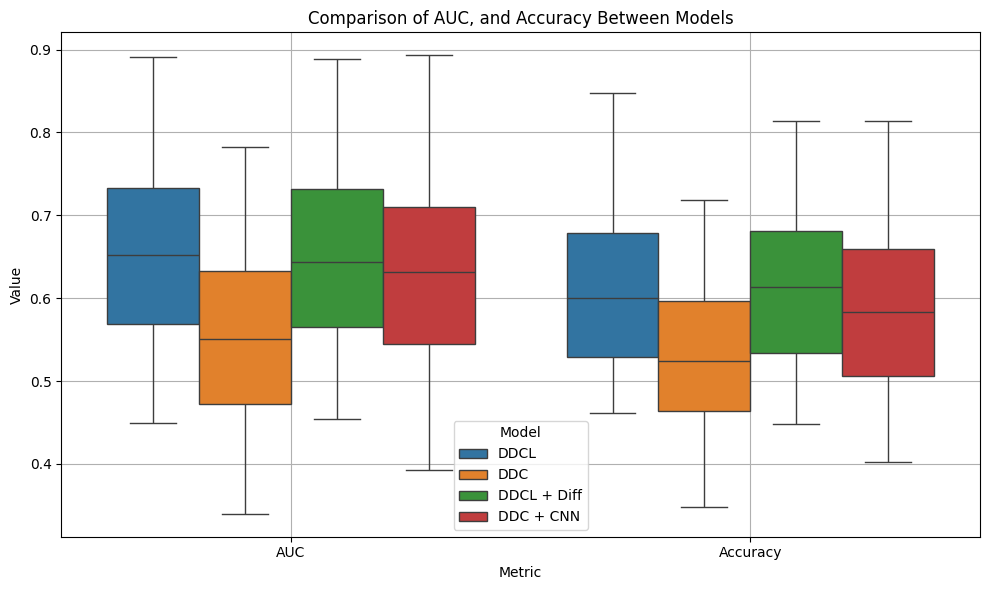

In [27]:
# Prepare a dataframe for seaborn
data = {
    'AUC': AUCs + AUCs_ddc + AUCs_diff + AUCs_conv3d,
    'Accuracy': Accs + Accs_ddc + Accs_diff + Accs_conv3d,
    #'Hold Accuracy': HoldAccs + HoldAccs_ddc + HoldAccs_diff + HoldAccs_conv3d,
    #'Step Accuracy': StepAccs + StepAccs_ddc + StepAccs_diff + StepAccs_conv3d,
    'Model': (['DDCL'] * len(losses_ddc)) + (['DDC'] * len(losses_ddc)) + (['DDCL + Diff'] * len(losses_diff)) + (['DDC + CNN'] * len(losses_conv3d))
}

df = pd.DataFrame(data)

# Melt the dataframe to long-form for seaborn
df_melted = pd.melt(df, id_vars='Model', var_name='Metric', value_name='Value')

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Metric', y='Value', hue='Model', data=df_melted)
plt.title('Comparison of AUC, and Accuracy Between Models')
plt.grid(True)
plt.tight_layout()
plt.savefig('figs/auc_acc_sym.png')
plt.show()

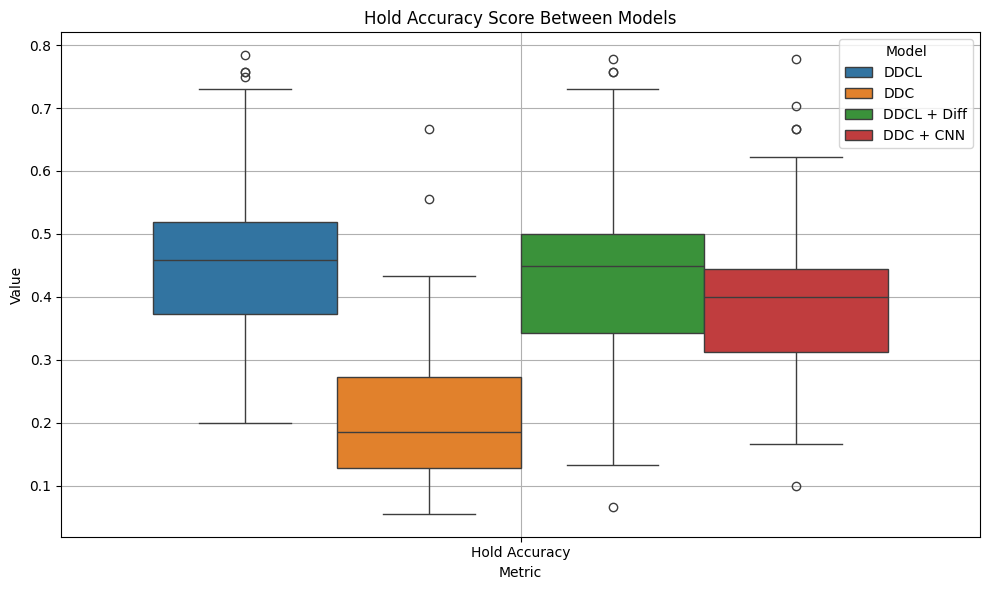

In [28]:
datasets = [HoldAccs, HoldAccs_ddc, HoldAccs_diff, HoldAccs_conv3d]
datasets_names = [['DDCL'],['DDC'],['DDCL + Diff'], ['DDC + CNN']]
datasets_dict = dict(zip(datasets_names, datasets))
data_in = sum(datasets)
data_names = sum([datum * len(datasets_dict[datum] for datum in datasets_names)])
data = {
    'Hold Accuracy': data_in,
    'Model': data_names
}

df = pd.DataFrame(data)

df_melted = pd.melt(df, id_vars='Model', var_name='Metric', value_name='Value')

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Metric', y='Value', hue='Model', data=df_melted)
plt.title('Hold Accuracy Score Between Models')
plt.grid(True)
plt.tight_layout()
plt.savefig('figs/hold_score_sym.png')
plt.show()

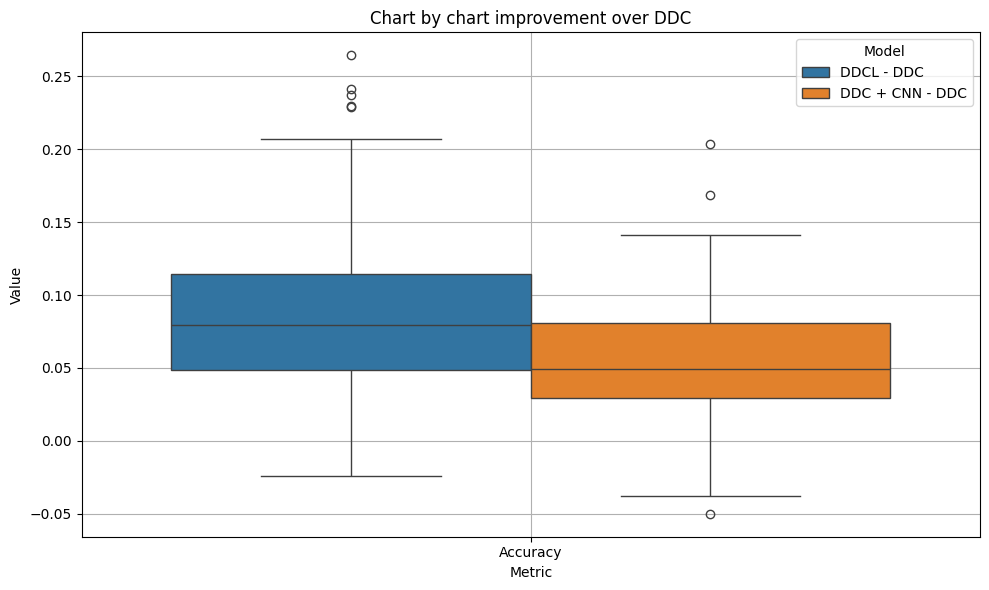

In [29]:
# Prepare a dataframe for seaborn
data = {
    'Accuracy': list(np.array(Accs) - np.array(Accs_ddc)) + list(np.array(Accs_conv3d) - np.array(Accs_ddc)),
    'Model': (['DDCL - DDC'] * len(losses_ddc)) + (['DDC + CNN - DDC'] * len(losses_ddc))
}

df = pd.DataFrame(data)

# Melt the dataframe to long-form for seaborn
df_melted = pd.melt(df, id_vars='Model', var_name='Metric', value_name='Value')

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Metric', y='Value', hue='Model', data=df_melted)
plt.title('Chart by chart improvement over DDC')
plt.grid(True)
plt.tight_layout()
plt.savefig('figs/ddc_imp_sym.png')
plt.show()

In [11]:
def generatorify_from_fp_list(dataset_fp_list, 
                              memlen = 7, 
                              aud_memlen = 7, 
                              batch_size = 50, 
                              mem_size = 50000, 
                              shuffle = False, 
                              bidirectional_audio = True, 
                              use_diff = False):
    def _gener():
        k = 0
        hopper = 0
        song = None
        while True:
            while hopper < mem_size:
                if k == len(dataset_fp_list)-1:
                    return
                with open(dataset_fp_list[k], 'rb') as f:
                    charts = pickle.load(f)
                k += 1
                for chart in charts:
                    newsong = [[a[i] for a in chart] for i in range(3)]
                    mean = np.mean(newsong[2], axis = 0)
                    std = np.std(newsong[2], axis = 0)
                    newsong[2] = (np.array(newsong[2])-mean)/std

                    newsong[1] = [sparse_to_categorical(sparceify([int(a) for a in list(b)]), 255) for b in newsong[1]]
                    newsong[1] = windowize(np.array(newsong[1]), frames=memlen)
                    newsong[0].append(0)
                    if use_diff:
                        newsong[0] = [[newsong[0][i], newsong[0][i+1], chart[0][3]] for i in range(len(newsong[0])-1)]
                    else:
                        newsong[0] = [[newsong[0][i], newsong[0][i+1]] for i in range(len(newsong[0])-1)]
                    newsong[0] = windowize(np.array(newsong[0]), frames = memlen)
                    newsong[1] = np.concatenate((newsong[1],newsong[0]), axis = -1)
                    newsong[2], newsong[0] = windowize(newsong[2], frames = aud_memlen, front_set = 'min'), windowize(newsong[2], frames = aud_memlen, front_set = 'min', go_backwards = True)

                    if song is None:
                        song = newsong
                    else:
                        for j in range(3):
                            song[j] = np.append(song[j],newsong[j], axis = 0)
                    hopper = len(song[0])

                if shuffle == True:
                    for i in range(3):
                        np.random.seed(seed)
                        song[i] = np.random.permutation(song[i])
                gc.collect()
            gc.collect()
                
            assert len(song[0])>batch_size

            success_take = 0
            miss_take = 0
            ac = []
            ac2 = []
            sd = []
            lb = []
            i = 0
            stick_on_shape = list(song[2].shape)
            while success_take<batch_size:
                if sum(song[1][i][-1])!=0:
                    if bidirectional_audio:
                        ac.append(song[2][i])
                        ac2.append(song[0][i])
                    else:
                        ac.append(song[2][i])
                    sd.append(list(song[1][i][:-1])+[[0 for j in range(narrow_types**4)]+list(song[1][i][-1][-(2+use_diff):])])
                    lb.append(song[1][i][-1][:-(2+use_diff)])
                    success_take += 1
                else:
                    miss_take += 1
                i+=1
            ac, ac2, sd, lb = np.array(ac), np.array(ac2), np.array(sd), np.array(lb)
            for j in range(3):
                song[j] = song[j][int(batch_size + miss_take):]
            hopper -= (batch_size + miss_take)
            if bidirectional_audio:
                yield(ac,ac2,sd), lb
            else:
                yield (ac,sd), lb
    return _gener()



def get_inputs_and_gens(vld_fp, shuffle = False, batch_size = 1000, bidirectional_audio = True, memlen = 64, aud_memlen = 15, use_diff = False):
    vld_ds = get_dataset_fp_list(vld_fp)

    valid_gen = generatorify_from_fp_list(vld_ds, 
                                          batch_size=batch_size, 
                                          shuffle = shuffle, 
                                          mem_size=batch_size+1, 
                                          memlen=memlen, 
                                          aud_memlen=aud_memlen, 
                                          bidirectional_audio=bidirectional_audio, 
                                          use_diff = use_diff)

    return valid_gen

In [12]:
def generatorify_from_fp_list_ddc(dataset_fp_list, 
                                  memlen = 7, 
                                  aud_memlen = 7, 
                                  batch_size = 50, 
                                  mem_size = 50000, 
                                  shuffle = False, 
                                  bidirectional_audio = True):
    def _gener():
        k = 0
        hopper = 0
        song = None
        while True:
            while hopper < mem_size:
                if k == len(dataset_fp_list)-1:
                    return
                with open(dataset_fp_list[k], 'rb') as f:
                    charts = pickle.load(f)
                k += 1
                for chart in charts:
                    newsong = [[a[0] for a in chart], [a[1] for a in chart], [a[1] for a in chart]]
                    newsong[1] = [ddc_string_to_step(b) for b in newsong[1]]
                    newsong[1] = windowize(np.array(newsong[1]), frames=memlen)
                    newsong[0].append(0)
                    newsong[0] = [[newsong[0][i], newsong[0][i+1], 0] for i in range(len(newsong[0])-1)]
                    newsong[0][0][2] = 1
                    newsong[0] = windowize(np.array(newsong[0]), frames = memlen)
                    newsong[0] = np.concatenate((newsong[1],newsong[0]), axis = -1)
                    if song is None:
                        song = newsong
                    else:
                        for j in range(3):
                            song[j] = np.append(song[j],newsong[j], axis = 0)
                    hopper += len(newsong[0])

                if shuffle == True:
                    for i in range(3):
                        np.random.seed(seed)
                        song[i] = np.random.permutation(song[i])
                gc.collect()
            gc.collect()
                
            assert len(song[0])>batch_size+memlen

            success_take = 0
            miss_take = 0
            sd = []
            lb = []
            i = 0
            while success_take<batch_size:
                sd.append(list(song[0][i][:-1])+[[0 for j in range(narrow_types*4)]+list(song[0][i][-1][-3:])])    
                lb.append(sparse_to_categorical(sparceify([int(a) for a in list(song[2][i])]), 255))
                success_take += 1
                i += 1
            sd, lb = np.array(sd), np.array(lb)
            for j in range(3):
                song[j] = song[j][int(batch_size + miss_take):]
            hopper -= batch_size
            yield sd, lb
    return _gener()



def get_inputs_and_gens_ddc(vld_fp, shuffle = False, batch_size = 1000, bidirectional_audio = True, memlen = 64, aud_memlen = 15):
    vld_ds = get_dataset_fp_list(vld_fp)

    valid_gen = generatorify_from_fp_list_ddc(vld_ds, 
                                          batch_size=batch_size, 
                                          shuffle = shuffle, 
                                          mem_size=3*batch_size+memlen, 
                                          memlen=memlen, 
                                          aud_memlen=aud_memlen, 
                                          bidirectional_audio=bidirectional_audio)

    return valid_gen

In [13]:
sym_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits = False),
    metrics=[
    tf.keras.metrics.AUC(from_logits = False, curve = 'PR'),
    tf.keras.metrics.CategoricalAccuracy(),
    MaskedCategoricalAccuracy(ignore_classes),
    MaskedCategoricalAccuracy(step_classes, name = 'step_mask')
],
)
sym_model_ddc.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits = False),
    metrics=[
    tf.keras.metrics.AUC(from_logits = False, curve = 'PR'),
    tf.keras.metrics.CategoricalAccuracy(),
    MaskedCategoricalAccuracy(ignore_classes),
    MaskedCategoricalAccuracy(step_classes, name = 'step_mask')
],
)
sym_model_diff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits = False),
    metrics=[
    tf.keras.metrics.AUC(from_logits = False, curve = 'PR'),
    tf.keras.metrics.CategoricalAccuracy(),
    MaskedCategoricalAccuracy(ignore_classes),
    MaskedCategoricalAccuracy(step_classes, name = 'step_mask')
],
)
sym_model_conv3d.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits = False),
    metrics=[
    tf.keras.metrics.AUC(from_logits = False, curve = 'PR'),
    tf.keras.metrics.CategoricalAccuracy(),
    MaskedCategoricalAccuracy(ignore_classes),
    MaskedCategoricalAccuracy(step_classes, name = 'step_mask')
],
)
valid_gen = get_inputs_and_gens(valid_txt_fp,
                                shuffle, 
                                batch_size=batch_size, 
                                bidirectional_audio = bidirectional_audio, 
                                memlen=memlen, 
                                aud_memlen=aud_memlen)
valid_gen_conv3d = get_inputs_and_gens(valid_txt_fp,
                                shuffle, 
                                batch_size=batch_size, 
                                bidirectional_audio = bidirectional_audio, 
                                memlen=memlen, 
                                aud_memlen=aud_memlen)
valid_gen_diff = get_inputs_and_gens(valid_txt_fp,
                                shuffle, 
                                batch_size=batch_size, 
                                bidirectional_audio = bidirectional_audio, 
                                memlen=memlen, 
                                aud_memlen=aud_memlen, 
                                use_diff = True)
valid_gen_ddc = get_inputs_and_gens_ddc(valid_txt_fp,
                                shuffle, 
                                batch_size=batch_size, 
                                memlen=memlen)

loss_ddc, AUC_ddc, Accuracy_ddc, HoldAcc_ddc, StepAcc_ddc = sym_model_ddc.evaluate(valid_gen_ddc, steps = 10000)
loss, AUC, Accuracy, HoldAcc, StepAcc = sym_model.evaluate(valid_gen, steps = 10000)
loss_diff, AUC_diff, Accuracy_diff, HoldAcc_diff, StepAcc_diff = sym_model_diff.evaluate(valid_gen_diff, steps = 10000)
loss_conv3d, AUC_conv3d, Accuracy_conv3d, HoldAcc_conv3d, StepAcc_conv3d = sym_model_conv3d.evaluate(valid_gen_conv3d, steps = 10000)

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 330s 33ms/step - auc_17: 0.5284 - categorical_accuracy: 0.4991 - loss: 1.3844 - masked_categorical_accuracy: 0.1836 - step_mask: 0.5386  


2025-05-26 18:51:50.146572: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 2182699667851275323
2025-05-26 18:51:50.146606: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 2773745603028456104
2025-05-26 18:51:50.146614: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 5752275808801353066


10000/10000 ━━━━━━━━━━━━━━━━━━━━ 413s 41ms/step - auc_16: 0.6335 - categorical_accuracy: 0.5839 - loss: 1.0714 - masked_categorical_accuracy: 0.4384 - step_mask: 0.6020  


2025-05-26 18:58:53.195424: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_6]]
2025-05-26 18:58:53.195482: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 6068139042356746579
2025-05-26 18:58:53.195496: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 2854648999394545597


10000/10000 ━━━━━━━━━━━━━━━━━━━━ 426s 43ms/step - auc_18: 0.6272 - categorical_accuracy: 0.5828 - loss: 1.0880 - masked_categorical_accuracy: 0.4340 - step_mask: 0.6013  


2025-05-26 19:06:10.016639: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 6068139042356746579
2025-05-26 19:06:10.016670: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 2854648999394545597
2025-05-26 19:06:10.016683: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 7428599513538605506
2025-05-26 19:06:10.016692: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 1645998552633588558
2025-05-26 19:06:10.016701: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 10068097546953836354


10000/10000 ━━━━━━━━━━━━━━━━━━━━ 427s 43ms/step - auc_19: 0.6074 - categorical_accuracy: 0.5619 - loss: 1.1347 - masked_categorical_accuracy: 0.3891 - step_mask: 0.5836  


2025-05-26 19:13:27.377196: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 2897879102572716167
2025-05-26 19:13:27.377223: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 13928722209606605455
2025-05-26 19:13:27.377234: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 18323137761383184426
2025-05-26 19:13:27.377241: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 6258297163648248610
2025-05-26 19:13:27.377247: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 15543061641740508618


In [14]:
data = {
    "Model": ["sym_model", "sym_model_ddc", "sym_model_diff", "sym_model_conv3d"],
    "Loss": [loss, loss_ddc, loss_diff, loss_conv3d],
    "AUC (PR)": [AUC, AUC_ddc, AUC_diff, AUC_conv3d],
    "Accuracy": [Accuracy, Accuracy_ddc, Accuracy_diff, Accuracy_conv3d],
    "HoldAcc": [HoldAcc, HoldAcc_ddc, HoldAcc_diff, HoldAcc_conv3d],
    "StepAcc": [StepAcc, StepAcc_ddc, StepAcc_diff, StepAcc_conv3d]
}

# Create DataFrame
df = pd.DataFrame(data)

# Optionally round for better readability
df_rounded = df.copy()
df_rounded.iloc[:, 1:] = df_rounded.iloc[:, 1:].astype(float).round(4)

# Display table
print(df_rounded)

# Export to LaTeX
latex_table = df_rounded.to_latex(index=False, caption="Model Evaluation Metrics", label="tab:model_evaluation", column_format="lccccc")
print(latex_table)

              Model    Loss  AUC (PR)  Accuracy  HoldAcc  StepAcc
0         sym_model  1.0790    0.6306    0.5814   0.4338   0.5998
1     sym_model_ddc  1.3896    0.5256    0.4974   0.1827   0.5369
2    sym_model_diff  1.0980    0.6236    0.5801   0.4279   0.5991
3  sym_model_conv3d  1.1441    0.6033    0.5589   0.3844   0.5808
\begin{table}
\caption{Model Evaluation Metrics}
\label{tab:model_evaluation}
\begin{tabular}{lccccc}
\toprule
Model & Loss & AUC (PR) & Accuracy & HoldAcc & StepAcc \\
\midrule
sym_model & 1.079000 & 0.630600 & 0.581400 & 0.433800 & 0.599800 \\
sym_model_ddc & 1.389600 & 0.525600 & 0.497400 & 0.182700 & 0.536900 \\
sym_model_diff & 1.098000 & 0.623600 & 0.580100 & 0.427900 & 0.599100 \\
sym_model_conv3d & 1.144100 & 0.603300 & 0.558900 & 0.384400 & 0.580800 \\
\bottomrule
\end{tabular}
\end{table}



In [20]:
data = {
    "Model": ["DDCL", "DDC", "DDCL + Diff", "DDC + CNN"],
    "Loss": [np.mean(losses), np.mean(losses_ddc), np.mean(losses_diff), np.mean(losses_conv3d)],
    "AUC (PR)": [np.mean(AUC), np.mean(AUC_ddc), np.mean(AUC_diff), np.mean(AUC_conv3d)],
    "Accuracy": [np.mean(Accs), np.mean(Accs_ddc), np.mean(Accs_diff), np.mean(Accs_conv3d)],
    "Hold Acc.": [np.mean(HoldAccs), np.mean(HoldAccs_ddc), np.mean(HoldAccs_diff), np.mean(HoldAccs_conv3d)],
    "Step Acc.": [np.mean(StepAccs), np.mean(StepAccs_ddc), np.mean(StepAccs_diff), np.mean(StepAccs_conv3d)]
}

# Create DataFrame
df = pd.DataFrame(data)

# Optionally round for better readability
df_rounded = df.copy()
df_rounded.iloc[:, 1:] = df_rounded.iloc[:, 1:].astype(float).round(4)

# Display table
print(df_rounded)

# Export to LaTeX
latex_table = df_rounded.to_latex(index=False, caption="Model Evaluation Metrics", label="tab:model_evaluation", column_format="lccccc")
print(latex_table)

         Model    Loss  AUC (PR)  Accuracy  Hold Acc.  Step Acc.
0         DDCL  1.0085    0.8100    0.6160     0.4533     0.6282
1          DDC  1.3073    0.5256    0.5334     0.2100     0.5611
2  DDCL + Diff  1.0294    0.6236    0.6117     0.4339     0.6246
3    DDC + CNN  1.0803    0.6033    0.5876     0.3911     0.6029
\begin{table}
\caption{Model Evaluation Metrics}
\label{tab:model_evaluation}
\begin{tabular}{lccccc}
\toprule
Model & Loss & AUC (PR) & Accuracy & Hold Acc. & Step Acc. \\
\midrule
DDCL & 1.008500 & 0.810000 & 0.616000 & 0.453300 & 0.628200 \\
DDC & 1.307300 & 0.525600 & 0.533400 & 0.210000 & 0.561100 \\
DDCL + Diff & 1.029400 & 0.623600 & 0.611700 & 0.433900 & 0.624600 \\
DDC + CNN & 1.080300 & 0.603300 & 0.587600 & 0.391100 & 0.602900 \\
\bottomrule
\end{tabular}
\end{table}

